<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-WK8-Group-Assignment/blob/main/EMSC2010_Group_Project_WK8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Cloudy with a chance of stats

Project week: 8

Project title: When will the steps of the Sydney Opera House be submerged from rising ocean levels due to Greenland ice melt?

Datasets used (name and source):

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Deadline |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Leo | Cathy | Yes/Partial/No| 1/05|
| Data steward | Cathy | Elena | Yes/Partial/No| 1/05|
| Analysis / modelling | Elena | Sutton | Yes/Partial/No| 3/05|
| Visualisation / interpretation | Sutton | Sameer | Yes/Partial/No| 4/05|
| Narrative | Sameer | Kimi | Yes/Partial/No| 6/05|
| Quality Control / Reproducibility  | Kimi | Leo | Yes/Partial/No/NA| 7/05|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected:

* Reason (e.g. missed deadline, absence, etc.):

* Deputy action taken:

* Impact on workflow:

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository.
* Commits include meaningful information.
* Each group member has included a brief reflection in the notebook.
* Repository has been shared with the teaching team once your project is completed.

# Start your group project here

**Project Overview**

**Data Import**

Greenland Ice Sheet melt data were collected by the Ice Sheet Mass Balance Inter-comparison Exercise (IMBIE). The Greenland Ice Sheet was selected because long-term observational data are readily available, and because it contains enough ice that, if fully melted, it could significantly contribute to global sea-level rise. As the dataset spans from 1972 to the end of 2025, it provides sufficient temporal coverage to sample predictive posterior distributions of future melt progression. The variable of interest is the cumulative mass balance of the ice sheet, measured in gigatonnes (Gt). No modifications were made to the dataset.

Data can be found here: https://climate.copernicus.eu/climate-indicators/ice-sheets

In [ ]:
import pandas as pd #used to read and clean data
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# This cell defines variables for the Excel spreadsheet and sheet names.
# These variables will be used later to import data from the specified sheets.
spreadsheet_name = 'Greenland_Data.xlsx' # Name of the Excel file containing the ice melt data.
Sheet1 = 'Data' # Name of the worksheet containing the data.

In [ ]:
Greenland_df = pd.read_excel(
    spreadsheet_name, # Pass the variable holding the Excel file name to `read_excel`.
    sheet_name=Sheet1, # Specify the sheet named 'Sheet1' to read data for Greenland
    skiprows=0,      # Skip the first row, as it contains headers that are not part of the data.
)
Greenland_df.head() # Display the first few rows of the created DataFrame to verify data loading and structure.

,Year,Mass balance (Gt/yr),Mass balance uncertainty (Gt/yr),Cumulative mass balance (Gt),Cumulative mass balance uncertainty (Gt)
0,1971.500000,65.9465,68.5751,5.495542,19.795927
1,1971.583333,65.9465,68.5751,10.991083,27.995668
2,1971.666667,65.9465,68.5751,16.486625,34.287551
3,1971.750000,65.9465,68.5751,21.982167,39.591853
4,1971.833333,65.9465,68.5751,27.477708,44.265038


**Data Analysis/Modelling**

1mm of sea level rise is equal to 361.8 Gt of ice melting.
Sea level rise was calculated using this website: https://www.antarcticglaciers.org/glaciers-and-climate/estimating-glacier-contribution-to-sea-level-rise/

From this code below, we know that sea levels have risen around 17.45mm since 1971 due to Greenland melting.

In [ ]:
year=Greenland_df['Year']   #read in dates from spreadsheet
mass=Greenland_df['Mass balance (Gt/yr)']   #read in yearly ice melt data from spreadsheet
sea_level_rise=mass/-361.8                  #convert to a sea level rise
cumul_mass=Greenland_df['Cumulative mass balance (Gt)']   #read in cumulative ice melt data from spreadsheet
sea_level_tot=cumul_mass/-361.8                           #convert to a sea level rise
sea_level_tot=sea_level_tot-sea_level_tot.iloc[-1]        #centre it so 0mm rise is 'today' and subsequent rise from there is easily calculated
print(sea_level_tot)

0     -17.461464
1     -17.476654
2     -17.491843
3     -17.507033
4     -17.522222
         ...    
649    -0.182602
650    -0.136952
651    -0.091301
652    -0.045651
653     0.000000
Name: Cumulative mass balance (Gt), Length: 654, dtype: float64


In [ ]:
!pip install bambi #system command to install bambi package

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 16.6 MB/s eta 0:00:00


In [ ]:
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models

In [ ]:
data = pd.DataFrame({"x": year, "y": sea_level_tot}) #put the data into a dataframe with variable names "x" and "y".
model = bmb.Model("y ~ {x**2}", data) #setup the second-order polynomial model
idata = model.fit(draws=2000, tune=2000, chains=8) #sample the posteriors

Output()

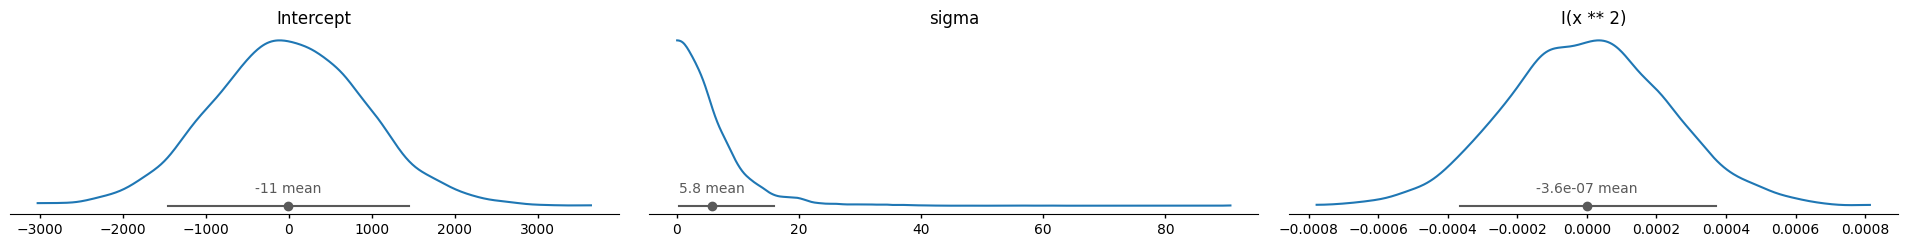

In [ ]:
## Checking the priors look good & make sense
model.plot_priors()
plt.tight_layout()
plt.show()

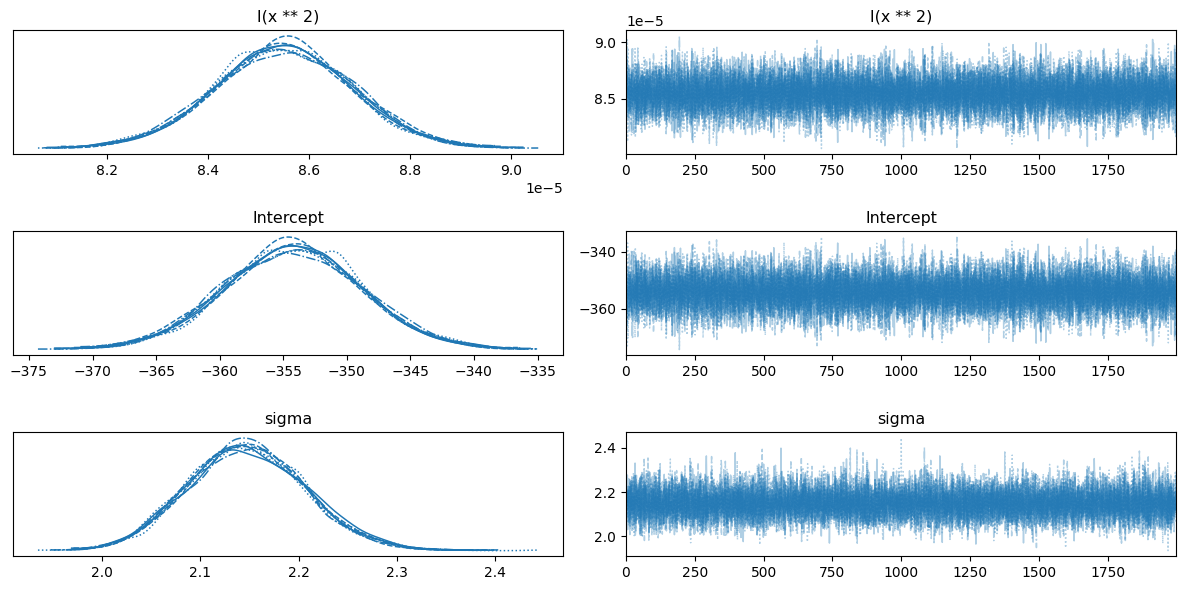

In [ ]:
az.plot_trace(idata);
plt.tight_layout() #this spaces the plots out so that they don't overlap

In [ ]:
# Predict across a range of x values
x_range = np.linspace(1971, 6500, 5000) # Predict across a range of x values from the year 1971 to 6500
new_data = pd.DataFrame({"x": x_range}) #dataframe with the new x-values
model.predict(idata, data=new_data, kind='response') #predict the distribution of gravel size at each x-value

# Make random draws from the posterior of the gravel size
y_pps_draws = idata.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution# Compute posterior mean and HDI at each x point
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata.posterior["mu"].values.reshape(-1, len(x_range)), hdi_prob=0.95)
hdi_pps = az.hdi(y_pps_draws, hdi_prob=0.95)

/tmp/ipykernel_7027/3531260183.py:14: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_mean = az.hdi(idata.posterior["mu"].values.reshape(-1, len(x_range)), hdi_prob=0.95)
/tmp/ipykernel_7027/3531260183.py:15: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_pps = az.hdi(y_pps_draws, hdi_prob=0.95)


In [ ]:
## Message from Elena: Hey! i tried to make the model a quadratic rather than a linear dependence but haven't graphed it yet, so
## i'm not sure if it actually worked. When you get around to graphing it i might check and if it doesn't work hopefully i can tweak some things

**Data Visualisation/Interpretation**

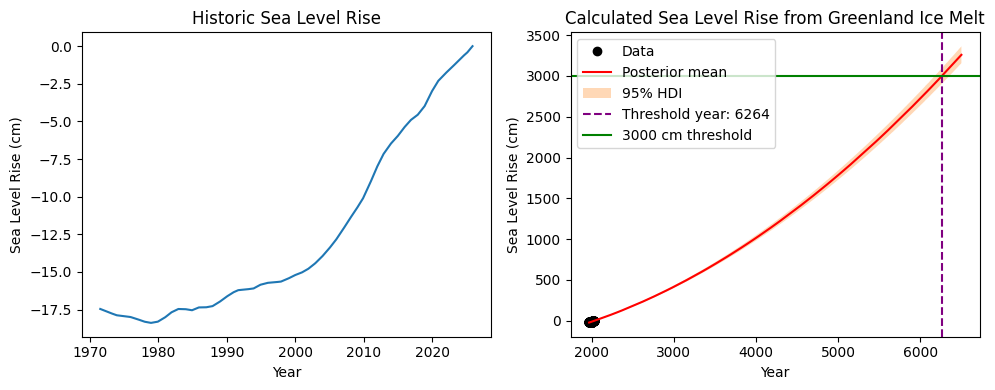

In [ ]:
#Plot the collected data and also the calculated posterior
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4)) #Create 2 subplots
ax1.plot(year, sea_level_tot) #On the first subplot, plot just the sourced sea level data
ax2.plot(year, sea_level_tot, 'ok', label="Data") #On the second subplot, plot the recorded sea level data
ax2.plot(x_range, posterior_mean, 'r', label="Posterior mean") #Add the posterior mean calculated sea level o the second subplot
plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI",
    edgecolor = None
) #Shade the highest density interval of the posterior mean on the second subplot

threshold_year = years_exceeding_3000[0] # Get the first year when sea level exceeds 3000cm

ax2.axvline(threshold_year, linestyle="--", color='purple', label=f"Threshold year: {threshold_year:.0f}")
ax2.axhline(3000, linestyle="-", color='green', label="3000 cm threshold") # Add a horizontal line for the 3000cm mark

ax1.set_title('Historic Sea Level Rise')
ax2.set_title('Calculated Sea Level Rise from Greenland Ice Melt')
ax1.set_xlabel('Year') #label x-axis for ax1
ax2.set_xlabel('Year') #label x-axis for ax2
ax1.set_ylabel('Sea Level Rise (cm)') #label y-axis for ax1
ax2.set_ylabel('Sea Level Rise (cm)') #label y-axis for ax2
plt.legend() #Add a legend to the plot
plt.tight_layout()
plt.show() #Show the plot

In [ ]:
#Find the HDI range at the threshold year
index_6264 = np.argmin(np.abs(x_range - 6264))
year_at_idx = x_range[idx_6264]
hdi_at_6264 = hdi_pps[idx_6264]

print(f"For the year closest to {year_at_idx:.0f} (index {idx_6264}):")
print(f"The 95% HDI range for sea level rise is from {hdi_at_6264[0]:.2f} cm to {hdi_at_6264[1]:.2f} cm")

For the year closest to 6264 (index 4739):
The 95% HDI range for sea level rise is from 2907.21 cm to 3097.33 cm


In [ ]:
#Calculate the percent of the HDI at the threhold year that is over the threshold
c = 3097.33-2907.21
p = 97.33/c
print(p)

0.511939827477383


Interpretation

The aim of our investigation was to calculate when the Sydney opera House steps would be submerged from rising sea levels due to the melting of the Greenland ice sheet. To submerge the steps sea level would have to rise an additional 3000cm from todays sea level which we have termed our threshold.

The above subplots show firstly, the recorded historic sea level rise upto present time and secondly the historical data and the posterior calculated mean sea level rise due to ice melt from Greenland. Superimposed upon the second subplot is also the highest density interval of the posterior and the lines marking the threshold. The 3000cm threshold is shown on the plot to be reached in the year 6264, with just over half (0.51) of the HDI at this point (2907.21 - 3097.33) also above the threshold.

It is important to note that this investigation is very arbitrary in that we only consider Greenland ice melt and not all the frozen water reservoirs across the world that will impact global sea level rise due to changing climate. Greenland only occupies around 10% of global land ice If all additions to the volume of the global ocean were accounted for the threshold would be reached earlier than 6264.

# **Reflections**

**Leo**

**Cathy**

This week my role consisted of finding and loading data related to the melt of the Greenland Ice Sheet. Due to satellite observational data being widely available from the partnership of NASA and the ESA through the Ice Sheet Mass Balance Inter-comparison Exercise, I was able to find data that recorded the changes in mass balance and cumulative mass balance of the ice sheet over time, as well as its uncertainties. There was no clean up needed to be done as there was data for each year and no outliers were observed after a quick plot of the Greenland Ice Sheet cumulative mass balance over time. I was able to then load up the data onto the colab project and define the sheet that contained the data Elena were going to analyse, as I created another worksheet in the excel file describing the figure metadata I could find. The first row of the sheet was skipped to make the analysis easier.


**Elena**

**Sutton**

**Sameer**

**Kimi**